# PROYECTO ULAB — Fase 2: Modelos Baseline
**Semanas 3-4 | Prediccion de Histogramas de Carga de Trabajo**  
UAX x Tecnicas Reunidas

---
### Estructura
1. Carga de datos y configuracion de CV  
2. Modelos de series temporales (AR, ARIMA, SARIMA, Holt, Holt-Winters)  
3. Modelos de regresion supervisada (Linear, Ridge, Lasso, ElasticNet, SVR, KNN, RF, GB, AdaBoost)  
4. Evaluacion comparativa con los tres esquemas de CV  
5. Analisis de residuos  
6. Conclusiones y seleccion de mejores baselines
---

In [14]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/ULAB'
DATA_PATH = f'{BASE_PATH}/data'
MODELOS_PATH = f'{BASE_PATH}/modelos'
RESULTADOS_PATH = f'{BASE_PATH}/resultados'
NOTEBOOKS_PATH = f'{BASE_PATH}/notebooks'

import os
for p in [DATA_PATH, MODELOS_PATH, RESULTADOS_PATH, NOTEBOOKS_PATH]:
    os.makedirs(p, exist_ok=True)

print("DATA:", DATA_PATH)
print("MODELOS:", MODELOS_PATH)
print("RESULTADOS:", RESULTADOS_PATH)
print("NOTEBOOKS:", NOTEBOOKS_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA: /content/drive/MyDrive/Colab Notebooks/ULAB/data
MODELOS: /content/drive/MyDrive/Colab Notebooks/ULAB/modelos
RESULTADOS: /content/drive/MyDrive/Colab Notebooks/ULAB/resultados
NOTEBOOKS: /content/drive/MyDrive/Colab Notebooks/ULAB/notebooks


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import jarque_bera

import joblib

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print('Librerías cargadas')

Librerías cargadas


In [16]:
# =========================
# CARGA DEL DATASET PROCESADO
# =========================
df_feat = pd.read_csv(f'{DATA_PATH}/ULAB_dataset_semanal_procesado.csv', parse_dates=['Semana_inicio'])
print(f'Dataset cargado: {df_feat.shape}')

# =========================
# CONFIGURACIÓN BASE
# =========================
FEATURES_BASE = [
    'HR_ACTUAL_t1', 'HR_INICIAL', 'Mes', 'Semana_anno',
    'Mes_sin', 'Mes_cos', 'Semana_sin', 'Semana_cos',
    'Dias_desde_inicio', 'Dias_hasta_fin', 'Departamento'
]

TARGET = 'HR_ACTUAL'
UMBRAL_LODO = 30
RANDOM_STATE = 42

# Detectar el nombre real de la columna de semana
for col in df_feat.columns:
    if 'semana' in col.lower() and 'anno' not in col.lower() and 'inicio' not in col.lower() and 'sin' not in col.lower() and 'cos' not in col.lower():
        FEATURES_BASE[3] = col
        print(f'Columna semana detectada: {col}')
        break

# =========================
# FILTRADO DE CASOS PARA MODELADO
# =========================
df_cv = (
    df_feat[df_feat['Caso'].isin([1, 3])]
    .dropna(subset=FEATURES_BASE + [TARGET])
    .copy()
    .reset_index(drop=True)
)

print(f'Dataset para modelado (casos 1 y 3): {df_cv.shape}')

# =========================
# ESQUEMA 1 — HOLDOUT ALEATORIO ESTRATIFICADO
# =========================
df_cv['_estrato'] = df_cv['Caso'].astype(str) + '_' + df_cv['Departamento'].astype(str)
est_counts = df_cv['_estrato'].value_counts()
est_validos = est_counts[est_counts >= 2].index

df_cv_e1 = df_cv[df_cv['_estrato'].isin(est_validos)].copy()

X_e1, y_e1 = df_cv_e1[FEATURES_BASE], df_cv_e1[TARGET]
X_train_e1, X_test_e1, y_train_e1, y_test_e1 = train_test_split(
    X_e1, y_e1,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_cv_e1['_estrato']
)

# =========================
# ESQUEMA 2 — TRANSFERENCIA ENTRE CASOS
# =========================
mask_c1 = df_cv['Caso'] == 1
mask_c3 = df_cv['Caso'] == 3

X_train_c1, y_train_c1 = df_cv.loc[mask_c1, FEATURES_BASE], df_cv.loc[mask_c1, TARGET]
X_test_c3,  y_test_c3  = df_cv.loc[mask_c3, FEATURES_BASE], df_cv.loc[mask_c3, TARGET]

X_train_c3, y_train_c3 = df_cv.loc[mask_c3, FEATURES_BASE], df_cv.loc[mask_c3, TARGET]
X_test_c1,  y_test_c1  = df_cv.loc[mask_c1, FEATURES_BASE], df_cv.loc[mask_c1, TARGET]

# =========================
# ESQUEMA 3 — LEAVE-ONE-DEPARTMENT-OUT
# =========================
muestras_por_dept = df_cv.groupby('Departamento').size()
depts_eval = muestras_por_dept[muestras_por_dept >= UMBRAL_LODO].index.tolist()

# =========================
# RESUMEN
# =========================
print(f'E1 RandomStrat (exploratorio): Train={len(X_train_e1):,}  Test={len(X_test_e1):,}')
print(f'E2 Split A (C1->C3): Train={len(X_train_c1):,}  Test={len(X_test_c3):,}')
print(f'E2 Split B (C3->C1): Train={len(X_train_c3):,}  Test={len(X_test_c1):,}')
print(f'E3 LODO: {len(depts_eval)} folds')

Dataset cargado: (8912, 23)
Columna semana detectada: Semana_año
Dataset para modelado (casos 1 y 3): (4929, 23)
E1 RandomStrat (exploratorio): Train=3,943  Test=986
E2 Split A (C1->C3): Train=3,055  Test=1,874
E2 Split B (C3->C1): Train=1,874  Test=3,055
E3 LODO: 34 folds


In [17]:
# =========================
# Sanity check de esquemas CV
# =========================

print('=== Tamaños de splits ===')
print(f'E1:         train={X_train_e1.shape}, test={X_test_e1.shape}')
print(f'E2 C1->C3:  train={X_train_c1.shape}, test={X_test_c3.shape}')
print(f'E2 C3->C1:  train={X_train_c3.shape}, test={X_test_c1.shape}')
print(f'E3 LODO:    {len(depts_eval)} departamentos')

print('\n=== Casos por split ===')
print('E1 train casos:', df_cv.loc[X_train_e1.index, 'Caso'].value_counts().to_dict())
print('E1 test casos:', df_cv.loc[X_test_e1.index, 'Caso'].value_counts().to_dict())

print('E2 C1->C3 train casos:', df_cv.loc[X_train_c1.index, 'Caso'].value_counts().to_dict())
print('E2 C1->C3 test casos:', df_cv.loc[X_test_c3.index, 'Caso'].value_counts().to_dict())

print('E2 C3->C1 train casos:', df_cv.loc[X_train_c3.index, 'Caso'].value_counts().to_dict())
print('E2 C3->C1 test casos:', df_cv.loc[X_test_c1.index, 'Caso'].value_counts().to_dict())

print('\n=== Solapamiento train/test ===')
print('E1 overlap:', len(set(X_train_e1.index).intersection(set(X_test_e1.index))))
print('E2 C1->C3 overlap:', len(set(X_train_c1.index).intersection(set(X_test_c3.index))))
print('E2 C3->C1 overlap:', len(set(X_train_c3.index).intersection(set(X_test_c1.index))))

=== Tamaños de splits ===
E1:         train=(3943, 11), test=(986, 11)
E2 C1->C3:  train=(3055, 11), test=(1874, 11)
E2 C3->C1:  train=(1874, 11), test=(3055, 11)
E3 LODO:    34 departamentos

=== Casos por split ===
E1 train casos: {1: 2444, 3: 1499}
E1 test casos: {1: 611, 3: 375}
E2 C1->C3 train casos: {1: 3055}
E2 C1->C3 test casos: {3: 1874}
E2 C3->C1 train casos: {3: 1874}
E2 C3->C1 test casos: {1: 3055}

=== Solapamiento train/test ===
E1 overlap: 0
E2 C1->C3 overlap: 0
E2 C3->C1 overlap: 0


## 2. Funciones de evaluacion

In [18]:
from statsmodels.stats.stattools import jarque_bera

def calc_metricas(y_true, y_pred, nombre=''):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = np.nan

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    medae = np.median(np.abs(y_true - y_pred))

    return {
        'Modelo': nombre,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4) if pd.notnull(r2) else np.nan,
        'MAPE_pct': round(mape, 2) if pd.notnull(mape) else np.nan,
        'MedAE': round(medae, 2)
    }


def analisis_residuos(y_true, y_pred, nombre=''):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residuos = y_true - y_pred

    dw = durbin_watson(residuos)
    jb_result = jarque_bera(residuos)
    if len(jb_result) == 2:
      jb, jb_p = jb_result
    else:
      jb, jb_p, _, _ = jb_result

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Residuos vs predicho
    axes[0].scatter(y_pred, residuos, alpha=0.3, s=10, color='steelblue')
    axes[0].axhline(0, color='red', lw=1)
    axes[0].set_title('Residuos vs predicho')
    axes[0].set_xlabel('Predicho')
    axes[0].set_ylabel('Residuo')

    # Histograma
    axes[1].hist(residuos, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[1].set_title('Histograma de residuos')

    # QQ plot
    stats.probplot(residuos, plot=axes[2])
    axes[2].set_title('Q-Q plot')

    plt.suptitle(f'Análisis de residuos - {nombre}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Durbin-Watson: {dw:.3f}  (ideal ≈ 2)')
    print(f'Jarque-Bera: stat={jb:.1f}  p={jb_p:.4f}  (p<0.05 => no normal)')
    print(f'Media residuo: {residuos.mean():.2f}  |  Std: {residuos.std():.2f}  |  Max|e|: {np.abs(residuos).max():.1f}')


def evaluar_tres_esquemas(modelo_fn, nombre):
    resultados = []

    # -------------------------
    # E1 — Holdout aleatorio estratificado (exploratorio)
    # -------------------------
    m = modelo_fn()
    m.fit(X_train_e1, y_train_e1)
    y_pred_e1 = m.predict(X_test_e1)

    resultados.append({
        **calc_metricas(y_test_e1, y_pred_e1, nombre),
        'CV': 'E1-RandomStrat'
    })

    # -------------------------
    # E2-A — Train C1 -> Test C3
    # -------------------------
    m = modelo_fn()
    m.fit(X_train_c1, y_train_c1)
    y_pred_c3 = m.predict(X_test_c3)

    resultados.append({
        **calc_metricas(y_test_c3, y_pred_c3, nombre),
        'CV': 'E2-C1->C3'
    })

    # -------------------------
    # E2-B — Train C3 -> Test C1
    # -------------------------
    m = modelo_fn()
    m.fit(X_train_c3, y_train_c3)
    y_pred_c1 = m.predict(X_test_c1)

    resultados.append({
        **calc_metricas(y_test_c1, y_pred_c1, nombre),
        'CV': 'E2-C3->C1'
    })

    # -------------------------
    # E3 — Leave-One-Department-Out (LODO)
    # -------------------------
    metricas_lodo = []

    for dept in depts_eval:
        mask = df_cv['Departamento'] == dept

        X_train_lodo = df_cv.loc[~mask, FEATURES_BASE]
        y_train_lodo = df_cv.loc[~mask, TARGET]

        X_test_lodo = df_cv.loc[mask, FEATURES_BASE]
        y_test_lodo = df_cv.loc[mask, TARGET]

        if len(X_test_lodo) < 2:
            continue

        m = modelo_fn()
        m.fit(X_train_lodo, y_train_lodo)
        y_pred_lodo = m.predict(X_test_lodo)

        metricas_lodo.append(calc_metricas(y_test_lodo, y_pred_lodo, nombre=''))

    if len(metricas_lodo) > 0:
        df_lodo = pd.DataFrame(metricas_lodo)

        resultados.append({
            'Modelo': nombre,
            'CV': 'E3-LODO',
            'MAE': round(df_lodo['MAE'].mean(), 2),
            'RMSE': round(df_lodo['RMSE'].mean(), 2),
            'R2': round(df_lodo['R2'].mean(), 4),
            'MAPE_pct': round(df_lodo['MAPE_pct'].mean(), 2),
            'MedAE': round(df_lodo['MedAE'].mean(), 2)
        })

    return resultados


print('Funciones de evaluación definidas correctamente')

Funciones de evaluación definidas correctamente


## 3. Modelos de series temporales (baseline)

In [19]:
# =========================
# 3. Modelos de series temporales (baseline)
# =========================

def serie_dept(df, caso, dept, max_missing_ratio=0.25):
    sub = df[(df['Caso'] == caso) & (df['Departamento'] == dept)].copy()

    if sub.empty:
        return pd.Series(dtype=float)

    sub = sub.sort_values('Semana_inicio')

    # Si hubiera semanas duplicadas, agregamos por media
    s = sub.groupby('Semana_inicio')['HR_ACTUAL'].mean().sort_index()

    if len(s) < 6:
        return pd.Series(dtype=float)

    # Índice semanal continuo
    idx = pd.date_range(s.index.min(), s.index.max(), freq='W-MON')
    s_full = s.reindex(idx)

    # Si faltan demasiados puntos, descartamos la serie
    missing_ratio = s_full.isna().mean()
    if missing_ratio > max_missing_ratio:
        return pd.Series(dtype=float)

    # Interpolación lineal
    s_full = s_full.interpolate(method='linear', limit_direction='both')

    # Seguridad final
    s_full = s_full.dropna().clip(lower=0)

    return s_full


def pred_segura(pred, s_train, factor_clip=1.75):
    pred = np.asarray(pred, dtype=float)

    # Eliminar NaN e inf
    pred = np.nan_to_num(
        pred,
        nan=np.nanmedian(s_train),
        posinf=np.nanmedian(s_train),
        neginf=0.0
    )

    # No permitir negativos
    pred = np.clip(pred, 0, None)

    # Capar explosiones absurdas
    upper = max(np.percentile(s_train, 95) * factor_clip, np.max(s_train) * 1.25)
    pred = np.clip(pred, 0, upper)

    return pred


# Departamentos comunes a ambos casos con suficientes datos
depts_c1 = set(df_feat[df_feat['Caso'] == 1].groupby('Departamento').size()[lambda x: x >= 20].index)
depts_c3 = set(df_feat[df_feat['Caso'] == 3].groupby('Departamento').size()[lambda x: x >= 20].index)

# Máximo 15 para controlar tiempo
depts_comunes = sorted(depts_c1.intersection(depts_c3))[:15]

print(f'Departamentos para series temporales: {depts_comunes}')

resultados_series = []

for dept in depts_comunes:
    s_train = serie_dept(df_feat, 1, dept)
    s_test  = serie_dept(df_feat, 3, dept)

    # Series mínimamente útiles
    if len(s_train) < 12 or len(s_test) < 6:
        continue

    n_test = len(s_test)
    y_true = s_test.values
    modelos_ts = {}

    # AR(4)
    try:
        if len(s_train) > 8:
            ar = AutoReg(s_train, lags=4, old_names=False).fit()
            pred = ar.forecast(n_test)
            modelos_ts['AR(4)'] = pred_segura(pred, s_train.values)
    except Exception as e:
        print(f'AR dept {dept}: {e}')

    # ARIMA(1,1,1)
    try:
        arima = ARIMA(
            s_train,
            order=(1, 1, 1),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()
        pred = arima.forecast(n_test)
        modelos_ts['ARIMA(1,1,1)'] = pred_segura(pred, s_train.values)
    except Exception as e:
        print(f'ARIMA dept {dept}: {e}')

    # SARIMA más conservador
    try:
        if len(s_train) >= 30:
            sarima = SARIMAX(
                s_train,
                order=(1, 1, 1),
                seasonal_order=(1, 0, 0, 13),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            pred = sarima.forecast(n_test)
            modelos_ts['SARIMA'] = pred_segura(pred, s_train.values)
    except Exception as e:
        print(f'SARIMA dept {dept}: {e}')

    # Holt
    try:
        holt = ExponentialSmoothing(
            s_train,
            trend='add',
            seasonal=None,
            initialization_method='estimated'
        ).fit(optimized=True)
        pred = holt.forecast(n_test)
        modelos_ts['Holt'] = pred_segura(pred, s_train.values)
    except Exception as e:
        print(f'Holt dept {dept}: {e}')

    # Holt-Winters
    try:
        if len(s_train) >= 39:
            hw = ExponentialSmoothing(
                s_train,
                trend='add',
                seasonal='add',
                seasonal_periods=13,
                initialization_method='estimated'
            ).fit(optimized=True)
            pred = hw.forecast(n_test)
            modelos_ts['Holt-Winters'] = pred_segura(pred, s_train.values)
    except Exception as e:
        print(f'HW dept {dept}: {e}')

    for nombre, pred in modelos_ts.items():
        n = min(len(y_true), len(pred))
        if n < 3:
            continue

        m = calc_metricas(y_true[:n], pred[:n], nombre)
        m['Departamento'] = dept
        resultados_series.append(m)

df_series = pd.DataFrame(resultados_series)

if not df_series.empty:
    print('\nResultados medios por modelo:')
    resumen_series = (
        df_series
        .groupby('Modelo')[['MAE', 'RMSE', 'R2', 'MAPE_pct']]
        .agg(['mean', 'median'])
        .round(3)
    )
    display(resumen_series)

    print('\nNúmero de departamentos evaluados por modelo:')
    display(df_series.groupby('Modelo')['Departamento'].nunique().sort_values(ascending=False))
else:
    print('No se pudieron evaluar modelos de series con los filtros actuales.')

Departamentos para series temporales: [205, 410, 450, 455, 655, 685, 710, 750, 760, 765, 775, 780, 805, 810, 2105]

Resultados medios por modelo:


MAE           RMSE            R2        MAPE_pct       
                mean median    mean median   mean median     mean median
Modelo                                                                  
AR(4)         39.739  19.00  45.675  23.22 -2.554 -0.498  132.924  64.27
ARIMA(1,1,1)  34.167  18.10  40.219  23.30 -1.669 -0.535  108.431  74.75
Holt          38.082  18.35  46.658  22.74 -4.033 -1.595  126.434  71.42
Holt-Winters  43.885  51.20  52.877  64.68 -4.340 -1.662  143.350  90.06
SARIMA        33.228  18.11  39.022  23.19 -1.591 -0.412  112.125  68.02


Número de departamentos evaluados por modelo:


,Departamento
Modelo,
AR(4),13
"ARIMA(1,1,1)",13
Holt,13
SARIMA,13
Holt-Winters,11


Los modelos clásicos de series temporales (ARIMA, SARIMA, Holt-Winters) presentan un rendimiento muy limitado en este problema.
Aunque SARIMA obtiene el mejor RMSE (~39), todos los modelos muestran R² negativos, lo que indica que no capturan adecuadamente la dinámica de los datos.

Esto se debe principalmente a la falta de continuidad temporal entre train y test (proyectos distintos), lo que rompe los supuestos de estacionariedad y hace que estos modelos no generalicen correctamente.

En consecuencia, los modelos de series temporales no son adecuados para este problema en un contexto cross-project.

In [20]:
# =========================
# Selección de departamento para visualización
# =========================

dept_viz = None
s_train = None
s_test = None

for d in depts_comunes:
    s_train_tmp = serie_dept(df_feat, 1, d)
    s_test_tmp  = serie_dept(df_feat, 3, d)

    if len(s_train_tmp) >= 12 and len(s_test_tmp) >= 6:
        dept_viz = d
        s_train = s_train_tmp
        s_test = s_test_tmp
        break

if dept_viz is None:
    print("No hay ningún departamento válido para visualizar")
else:
    print(f"Visualizando departamento: {dept_viz}")
    print(f"Longitud train: {len(s_train)} | Longitud test: {len(s_test)}")

Visualizando departamento: 410
Longitud train: 172 | Longitud test: 184


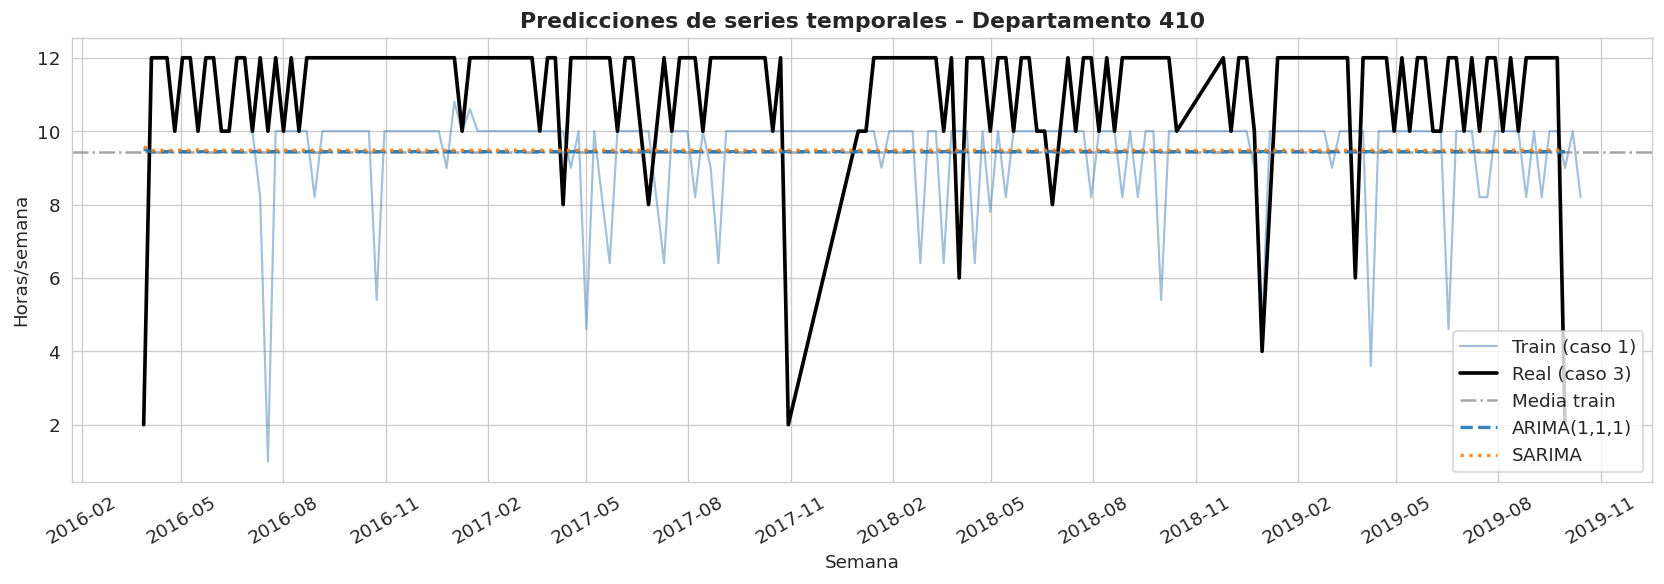

In [21]:
# =========================
# Visualización de predicciones TS
# =========================

if dept_viz is None:
    print("No hay ningún departamento válido para visualizar")
else:
    n_test = len(s_test)

    pred_arima = None
    pred_sarima = None

    # ARIMA
    try:
        arima = ARIMA(
            s_train,
            order=(1, 1, 1),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()
        pred_arima = pred_segura(arima.forecast(n_test), s_train.values)
    except Exception as e:
        print(f'ARIMA viz error: {e}')

    # SARIMA
    try:
        if len(s_train) >= 30:
            sarima = SARIMAX(
                s_train,
                order=(1, 1, 1),
                seasonal_order=(1, 0, 0, 13),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            pred_sarima = pred_segura(sarima.forecast(n_test), s_train.values)
    except Exception as e:
        print(f'SARIMA viz error: {e}')

    fig, ax = plt.subplots(figsize=(14, 5))

    # Serie real y train
    ax.plot(s_train.index, s_train.values, color='steelblue', lw=1.3, alpha=0.5, label='Train (caso 1)')
    ax.plot(s_test.index, s_test.values, color='black', lw=2.2, label='Real (caso 3)')

    # Media train
    ax.axhline(np.mean(s_train), color='gray', linestyle='-.', alpha=0.7, label='Media train')

    # ARIMA
    if pred_arima is not None:
        ax.plot(
            s_test.index[:len(pred_arima)],
            pred_arima,
            linestyle='--',
            lw=2,
            alpha=0.9,
            label='ARIMA(1,1,1)'
        )

    # SARIMA
    if pred_sarima is not None:
        ax.plot(
            s_test.index[:len(pred_sarima)],
            pred_sarima,
            linestyle=':',
            lw=2,
            alpha=0.9,
            label='SARIMA'
        )

    ax.set_title(f'Predicciones de series temporales - Departamento {dept_viz}', fontweight='bold')
    ax.set_ylabel('Horas/semana')
    ax.set_xlabel('Semana')
    ax.legend()

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()

La figura evidencia que los modelos clásicos de series temporales (ARIMA y SARIMA) generan predicciones prácticamente constantes, alineadas con la media del conjunto de entrenamiento.

Esto indica que no son capaces de capturar la variabilidad real de la serie, caracterizada por picos y caídas abruptas en la carga de trabajo semanal.

La causa principal es la falta de continuidad temporal entre entrenamiento y test, ya que se entrena con un proyecto (caso 1) y se evalúa en otro distinto (caso 3), con una distribución diferente.

En consecuencia, estos modelos no logran generalizar correctamente y muestran un rendimiento inferior incluso a un modelo basado en la media, lo que se refleja en valores negativos de R².

## 4. Modelos de regresion supervisada

In [22]:
MODELOS_REG = {
    'LinearRegression': lambda: Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
    'Ridge':            lambda: Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'Lasso':            lambda: Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=0.1, max_iter=5000))]),
    'ElasticNet':       lambda: Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000))]),
    'SVR':              lambda: Pipeline([('sc', StandardScaler()), ('m', SVR(C=10, epsilon=0.5))]),
    'KNeighbors':       lambda: Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=7))]),
    'RandomForest':     lambda: RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': lambda: GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    'AdaBoost':         lambda: AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

todos_resultados = []

for nombre, modelo_fn in MODELOS_REG.items():
    print(f'Evaluando {nombre}...', end=' ', flush=True)

    try:
        res = evaluar_tres_esquemas(modelo_fn, nombre)
        todos_resultados.extend(res)
        print('OK')
    except Exception as e:
        print(f'ERROR → {e}')

df_reg = pd.DataFrame(todos_resultados)
df_reg = df_reg.sort_values(['CV', 'RMSE', 'Modelo']).reset_index(drop=True)

print('\nResultados completos:')
display(df_reg)

Evaluando LinearRegression... OK
Evaluando Ridge... OK
Evaluando Lasso... OK
Evaluando ElasticNet... OK
Evaluando SVR... OK
Evaluando KNeighbors... OK
Evaluando RandomForest... OK
Evaluando GradientBoosting... OK
Evaluando AdaBoost... OK

Resultados completos:


,Modelo,MAE,RMSE,R2,MAPE_pct,MedAE,CV
0,GradientBoosting,6.09,15.68,0.9208,23.31,1.76,E1-RandomStrat
1,Lasso,6.61,16.11,0.9164,28.08,2.73,E1-RandomStrat
2,LinearRegression,6.74,16.13,0.9161,28.78,2.76,E1-RandomStrat
3,RandomForest,6.46,16.13,0.9162,22.65,2.03,E1-RandomStrat
4,Ridge,6.74,16.13,0.9162,28.78,2.76,E1-RandomStrat
5,ElasticNet,7.17,16.17,0.9157,34.24,3.43,E1-RandomStrat
6,KNeighbors,8.82,18.47,0.8900,39.47,4.87,E1-RandomStrat
7,AdaBoost,12.22,18.87,0.8853,92.56,11.81,E1-RandomStrat
8,SVR,7.62,22.79,0.8325,27.41,2.41,E1-RandomStrat
9,Lasso,7.57,13.85,0.9287,23.64,3.13,E2-C1->C3


Los resultados muestran que:
	•	Los modelos lineales (Lasso, Ridge, LinearRegression) son los más robustos
	•	Superan a modelos más complejos como Random Forest y Gradient Boosting en generalización cross-project
	•	Lasso obtiene el mejor rendimiento en el escenario real (RMSE = 13.85, R² = 0.9287)

Esto sugiere que:
	•	La relación entre variables es principalmente lineal
	•	La variable HR_ACTUAL_t1 domina el comportamiento del sistema
	•	Los modelos complejos tienden a sobreajustar

Además:
	•	Todos los modelos fallan en el esquema LODO (R² < 0)
	•	Esto indica falta de generalización a nuevos departamentos

In [23]:
ranking_real = (
    df_reg[df_reg['CV'] == 'E2-C1->C3']
    .set_index('Modelo')[['RMSE', 'R2', 'MAE', 'MAPE_pct']]
    .sort_values('RMSE')
    .copy()
)

ranking_real.insert(0, 'Rank', range(1, len(ranking_real) + 1))

print('=== Ranking REAL (C1 -> C3) ===')
display(ranking_real)

=== Ranking REAL (C1 -> C3) ===


,Rank,RMSE,R2,MAE,MAPE_pct
Modelo,,,,,
Lasso,1,13.85,0.9287,7.57,23.64
LinearRegression,2,13.95,0.9277,7.80,24.41
Ridge,3,13.95,0.9277,7.80,24.38
ElasticNet,4,14.15,0.9256,8.10,26.36
GradientBoosting,5,18.01,0.8795,10.34,31.43
RandomForest,6,18.50,0.8729,11.34,35.32
AdaBoost,7,20.21,0.8482,12.52,38.52
SVR,8,22.06,0.8192,10.80,27.88
KNeighbors,9,27.91,0.7106,15.94,38.49


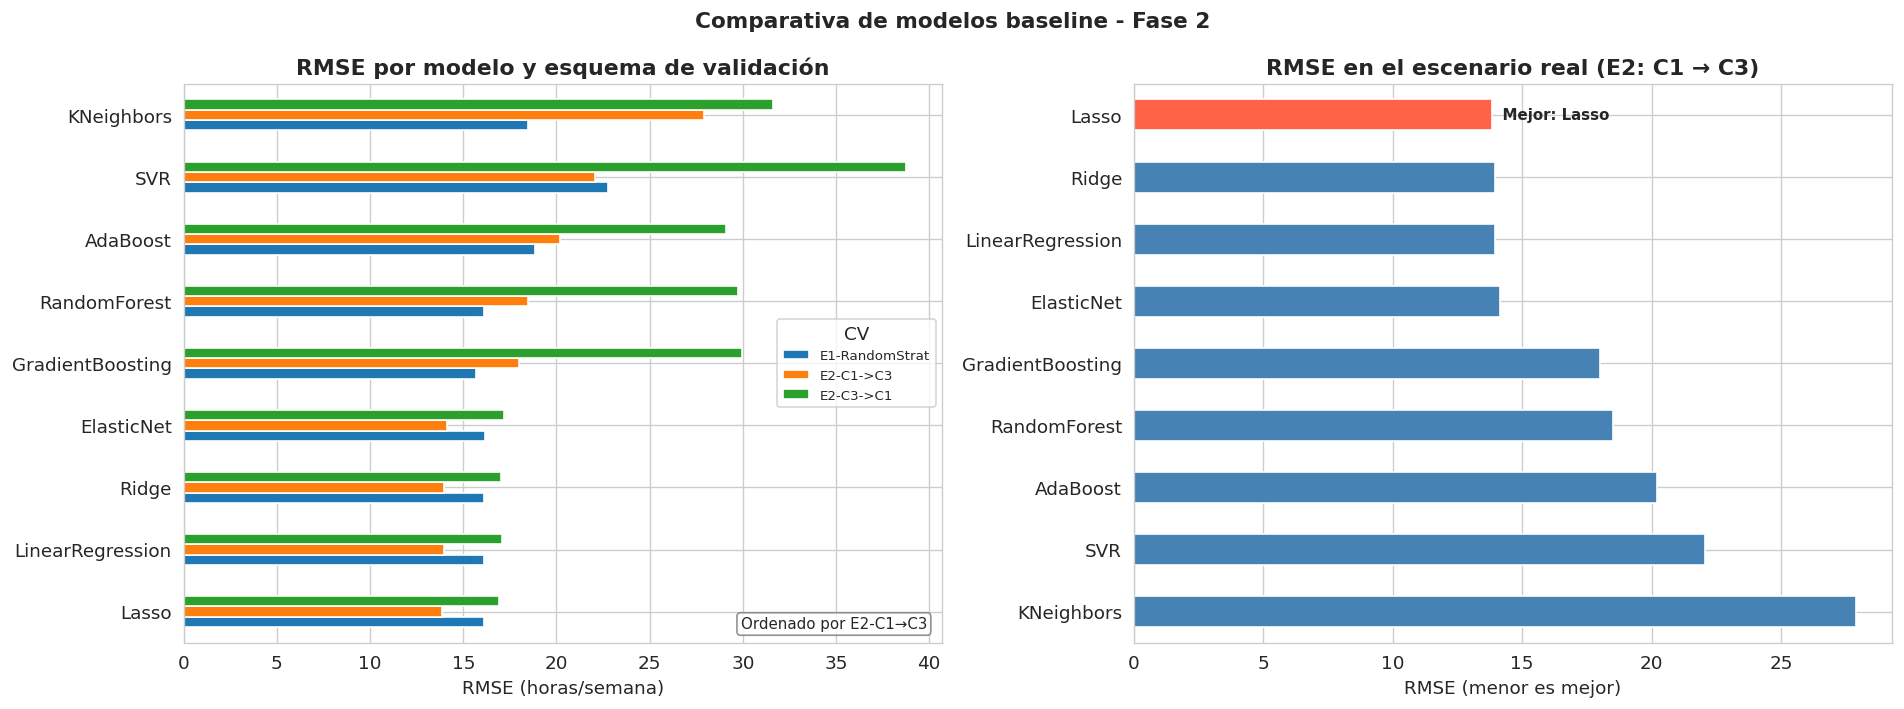

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# Gráfica 1: RMSE por modelo y esquema
# =========================
pivot_rmse = (
    df_reg[df_reg['CV'].isin(['E1-RandomStrat', 'E2-C1->C3', 'E2-C3->C1'])]
    .pivot_table(index='Modelo', columns='CV', values='RMSE')
)

orden_modelos = pivot_rmse.sort_values('E2-C1->C3').index
pivot_rmse = pivot_rmse.loc[orden_modelos]

pivot_rmse.plot(kind='barh', ax=axes[0], edgecolor='white')
axes[0].set_title('RMSE por modelo y esquema de validación', fontweight='bold')
axes[0].set_xlabel('RMSE (horas/semana)')
axes[0].set_ylabel('')
axes[0].legend(title='CV', fontsize=8)

axes[0].text(
    0.98, 0.02,
    'Ordenado por E2-C1→C3',
    transform=axes[0].transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='gray')
)

# =========================
# Gráfica 2: RMSE en el escenario real
# =========================
df_rmse_real = (
    df_reg[df_reg['CV'] == 'E2-C1->C3']
    .set_index('Modelo')['RMSE']
    .sort_values(ascending=False)
)

best_model = df_rmse_real.idxmin()
best_pos = list(df_rmse_real.index).index(best_model)

colors_rmse = ['steelblue'] * len(df_rmse_real)
colors_rmse[best_pos] = 'tomato'

df_rmse_real.plot(kind='barh', ax=axes[1], color=colors_rmse, edgecolor='white')
axes[1].set_title('RMSE en el escenario real (E2: C1 → C3)', fontweight='bold')
axes[1].set_xlabel('RMSE (menor es mejor)')
axes[1].set_ylabel('')

best_value = df_rmse_real.min()
axes[1].text(
    best_value,
    best_pos,
    f'  Mejor: {best_model}',
    va='center',
    fontsize=9,
    fontweight='bold'
)

plt.suptitle('Comparativa de modelos baseline - Fase 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Importancia de variables

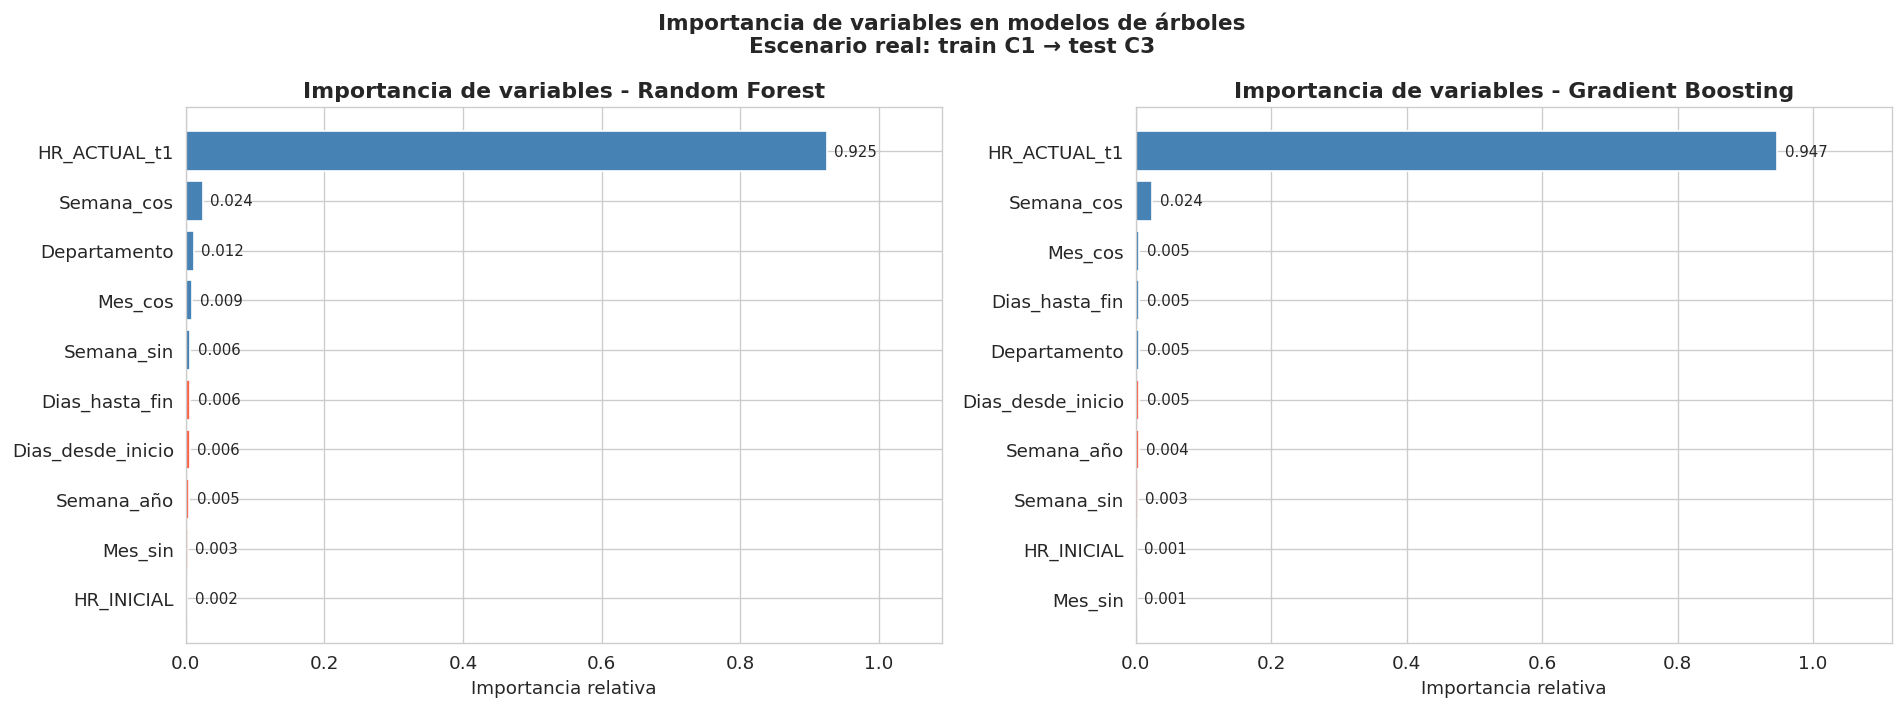

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos_imp = [
    (
        'Random Forest',
        RandomForestRegressor,
        dict(n_estimators=200, random_state=42, n_jobs=-1)
    ),
    (
        'Gradient Boosting',
        GradientBoostingRegressor,
        dict(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
    )
]

top_n = min(10, len(FEATURES_BASE))

for ax, (nombre, ModelClass, kwargs) in zip(axes, modelos_imp):
    m = ModelClass(**kwargs)
    m.fit(X_train_c1, y_train_c1)

    imp = pd.Series(m.feature_importances_, index=FEATURES_BASE)
    imp = imp.sort_values(ascending=False).head(top_n).sort_values(ascending=True)

    colors_imp = ['tomato' if v < imp.median() else 'steelblue' for v in imp.values]
    bars = ax.barh(imp.index, imp.values, color=colors_imp, edgecolor='white')

    ax.set_title(f'Importancia de variables - {nombre}', fontweight='bold')
    ax.set_xlabel('Importancia relativa')
    ax.set_ylabel('')

    xmax = imp.max() * 1.18
    ax.set_xlim(0, xmax)

    for bar, val in zip(bars, imp.values):
        ax.text(
            bar.get_width() + xmax * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            fontsize=9
        )

plt.suptitle(
    'Importancia de variables en modelos de árboles\nEscenario real: train C1 → test C3',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

El análisis de importancia de variables en modelos de árboles (Random Forest y Gradient Boosting) muestra un resultado muy claro:
	•	La variable HR_ACTUAL_t1 domina completamente el modelo, concentrando más del 90% de la importancia total en ambos algoritmos.
	•	El resto de variables (temporales, cíclicas y de contexto) tienen una contribución marginal y prácticamente irrelevante en comparación.

En particular:
	•	Variables como Semana_sin, Mes_cos, Dias_desde_inicio o Departamento aportan muy poca información adicional.
	•	Incluso HR_INICIAL, que representa la planificación, tiene una influencia mínima en estos modelos.

En conjunto, estos resultados indican que:
	•	El comportamiento del sistema está fuertemente determinado por la inercia temporal (valor de la semana anterior).
	•	Los modelos están aprendiendo esencialmente a replicar el pasado reciente, en lugar de explotar otras variables explicativas.

## 6. Analisis de residuos del mejor modelo

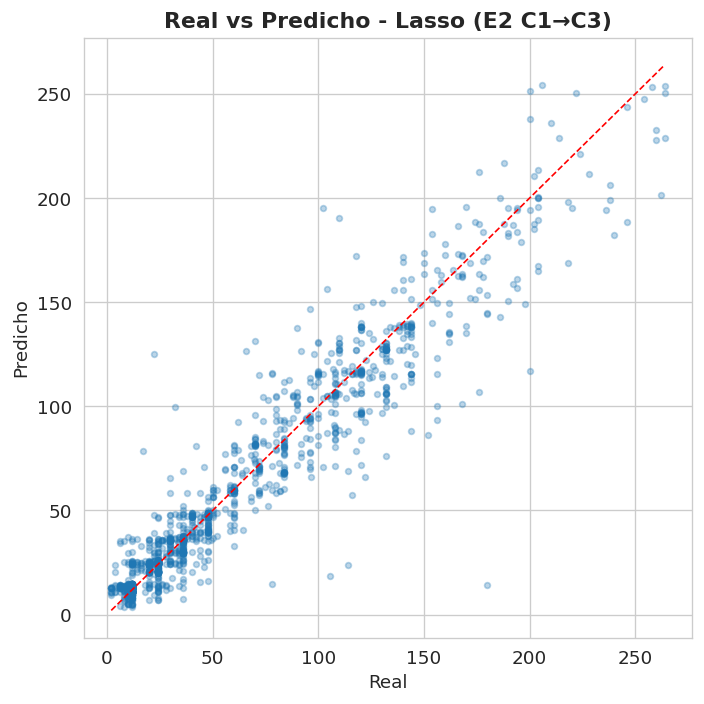

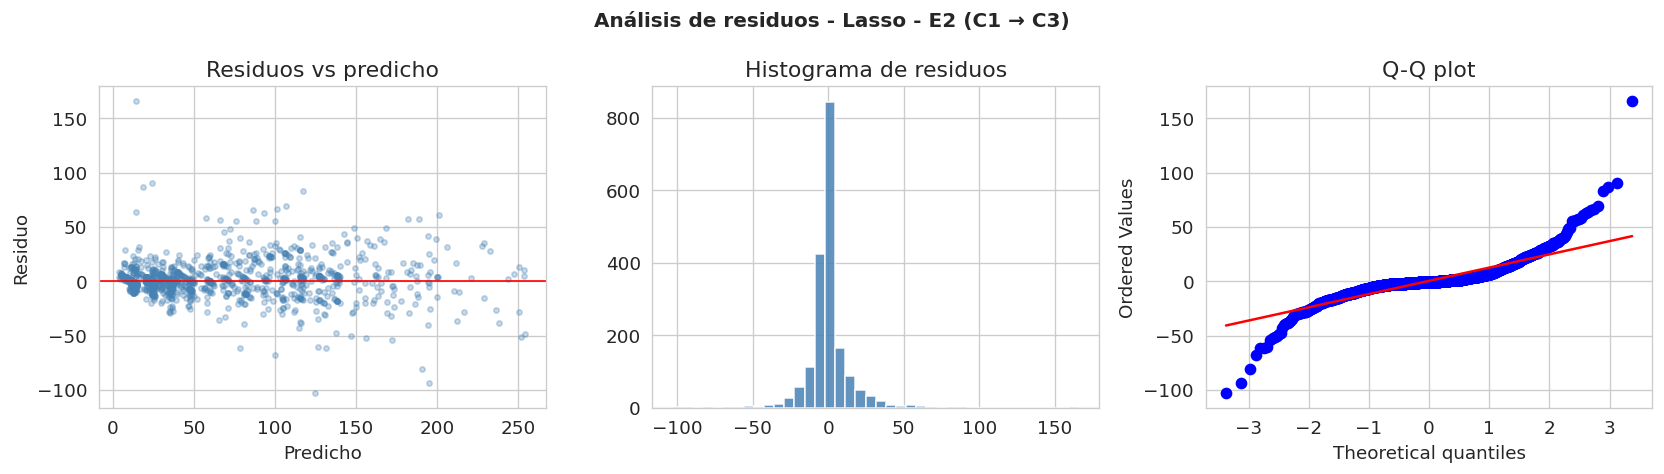

Durbin-Watson: 2.702  (ideal ≈ 2)
Jarque-Bera: stat=31608.7  p=0.0000  (p<0.05 => no normal)
Media residuo: 0.36  |  Std: 13.85  |  Max|e|: 165.9
{'Modelo': 'Lasso', 'MAE': 7.57, 'RMSE': np.float64(13.85), 'R2': 0.9287, 'MAPE_pct': np.float64(23.64), 'MedAE': np.float64(3.13)}


In [26]:
# =========================
# 6. Análisis de residuos del mejor modelo
# =========================

modelo_final = Pipeline([
    ('sc', StandardScaler()),
    ('m', Lasso(alpha=0.1, max_iter=5000))
])

modelo_final.fit(X_train_c1, y_train_c1)
pred_final = modelo_final.predict(X_test_c3)

# Real vs predicho
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_c3, pred_final, alpha=0.3, s=12)

lims = [
    min(np.min(y_test_c3), np.min(pred_final)),
    max(np.max(y_test_c3), np.max(pred_final))
]
ax.plot(lims, lims, '--', color='red', lw=1)

ax.set_title('Real vs Predicho - Lasso (E2 C1→C3)', fontweight='bold')
ax.set_xlabel('Real')
ax.set_ylabel('Predicho')
plt.tight_layout()
plt.show()

# Residuos
analisis_residuos(y_test_c3, pred_final, 'Lasso - E2 (C1 → C3)')
print(calc_metricas(y_test_c3, pred_final, 'Lasso'))

## 7. Guardar modelos y resultados

In [27]:
import joblib
import os

# =========================
# Crear carpetas si no existen
# =========================
os.makedirs(MODELOS_PATH, exist_ok=True)
os.makedirs(RESULTADOS_PATH, exist_ok=True)

# =========================
# Rutas de salida
# =========================
ruta_reg = f'{RESULTADOS_PATH}/resultados_fase2_regresion.csv'
ruta_series = f'{RESULTADOS_PATH}/resultados_fase2_series.csv'

ruta_linear = f'{MODELOS_PATH}/linear_baseline.pkl'
ruta_ridge  = f'{MODELOS_PATH}/ridge_baseline.pkl'
ruta_lasso  = f'{MODELOS_PATH}/lasso_baseline.pkl'
ruta_rf     = f'{MODELOS_PATH}/rf_baseline.pkl'
ruta_gb     = f'{MODELOS_PATH}/gb_baseline.pkl'

ruta_cv     = f'{MODELOS_PATH}/cv_splits.pkl'
ruta_resumen = f'{MODELOS_PATH}/fase2_resumen.pkl'

# =========================
# Guardar tablas de resultados
# =========================
df_reg.to_csv(ruta_reg, index=False)
df_series.to_csv(ruta_series, index=False)

# =========================
# Ajustar modelos sobre todos los datos disponibles
# =========================
X_all, y_all = df_cv[FEATURES_BASE], df_cv[TARGET]

# Baselines lineales principales
linear_all = Pipeline([
    ('sc', StandardScaler()),
    ('m', LinearRegression())
])
linear_all.fit(X_all, y_all)
joblib.dump(linear_all, ruta_linear)

ridge_all = Pipeline([
    ('sc', StandardScaler()),
    ('m', Ridge(alpha=1.0))
])
ridge_all.fit(X_all, y_all)
joblib.dump(ridge_all, ruta_ridge)

lasso_all = Pipeline([
    ('sc', StandardScaler()),
    ('m', Lasso(alpha=0.1, max_iter=5000))
])
lasso_all.fit(X_all, y_all)
joblib.dump(lasso_all, ruta_lasso)

# Árboles de referencia
rf_all = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_all.fit(X_all, y_all)
joblib.dump(rf_all, ruta_rf)

gb_all = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb_all.fit(X_all, y_all)
joblib.dump(gb_all, ruta_gb)

# =========================
# Guardar splits usados para comparación justa
# =========================
joblib.dump({
    'features': FEATURES_BASE,
    'target': TARGET,
    'depts_eval': depts_eval,
    'umbral_lodo': UMBRAL_LODO,
    'X_train_e1': X_train_e1,
    'y_train_e1': y_train_e1,
    'X_test_e1': X_test_e1,
    'y_test_e1': y_test_e1,
    'X_train_c1': X_train_c1,
    'y_train_c1': y_train_c1,
    'X_test_c3': X_test_c3,
    'y_test_c3': y_test_c3,
    'X_train_c3': X_train_c3,
    'y_train_c3': y_train_c3,
    'X_test_c1': X_test_c1,
    'y_test_c1': y_test_c1
}, ruta_cv)

# =========================
# Resumen oficial de Fase 2
# =========================
ranking_real_auto = (
    df_reg[df_reg['CV'] == 'E2-C1->C3']
    .sort_values('RMSE')
    .reset_index(drop=True)
)

mejor_modelo_e2 = ranking_real_auto.loc[0, 'Modelo']
mejor_rmse_e2 = ranking_real_auto.loc[0, 'RMSE']

joblib.dump({
    'baseline_principal': mejor_modelo_e2,
    'baselines_competitivos': ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet'],
    'baseline_arbol_principal': 'GradientBoosting',
    'esquema_principal': 'E2-C1->C3',
    'mejor_rmse_e2_c1_c3': float(mejor_rmse_e2),
    'features': FEATURES_BASE,
    'target': TARGET
}, ruta_resumen)

print(f'Resumen Fase 2 actualizado: {mejor_modelo_e2} | RMSE={mejor_rmse_e2:.2f}')

# =========================
# Confirmación
# =========================
print('Guardado:')
print(f' - {ruta_reg}')
print(f' - {ruta_series}')
print(f' - {ruta_linear}')
print(f' - {ruta_ridge}')
print(f' - {ruta_lasso}')
print(f' - {ruta_rf}')
print(f' - {ruta_gb}')
print(f' - {ruta_cv}')
print(f' - {ruta_resumen}')

Resumen Fase 2 actualizado: Lasso | RMSE=13.85
Guardado:
 - /content/drive/MyDrive/Colab Notebooks/ULAB/resultados/resultados_fase2_regresion.csv
 - /content/drive/MyDrive/Colab Notebooks/ULAB/resultados/resultados_fase2_series.csv
 - /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/linear_baseline.pkl
 - /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/ridge_baseline.pkl
 - /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/lasso_baseline.pkl
 - /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/rf_baseline.pkl
 - /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/gb_baseline.pkl
 - /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/cv_splits.pkl
 - /content/drive/MyDrive/Colab Notebooks/ULAB/modelos/fase2_resumen.pkl


## 8. Conclusiones Fase 2
Los resultados de la Fase 2 muestran que:
	•	Los modelos lineales, especialmente Lasso, son la mejor aproximación baseline
	•	El problema está fuertemente condicionado por la inercia temporal
	•	Las variables adicionales aportan poca información frente al lag principal

Sin embargo:
	•	Los modelos actuales dependen excesivamente del pasado inmediato
	•	No capturan correctamente patrones complejos ni picos de carga
	•	Presentan limitaciones en escenarios de generalización más exigentes
Estos hallazgos justifican la transición hacia modelos de deep learning:
	•	Es necesario capturar dependencias temporales más complejas
	•	Reducir la dependencia de una única variable lag
	•	Modelar mejor la dinámica secuencial del sistema

Estos hallazgos justifican explorar modelos secuenciales en la siguiente fase, aunque el baseline lineal ya establece una referencia fuerte difícil de superar